# Selekcja modelu, regularyzacja

## Zadania
1. Wczytaj zbiór `Hitters.csv`. Wybierz najlepszy model liniowy dla predykcji `Salary` na podstawie pozostałych zmiennych metodą *forward/backward selection*. 
    - Ignoruj kolumnę `PlayerName`. Usuń wiersze zawierające brakujące dane. 
    - Koduj zmienne kategoryczne metodą [`get_dummies()`](https://pandas.pydata.org/docs/reference/api/pandas.get_dummies.html).
    - Standaryzuj dane wejściowe (X) ([`StandardScaler`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.StandardScaler.html)/[`scale()`](https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.scale.html)).
    - Podziel dane na zbiór treningowy i testowy.
    - Selekcji można dokonać manualnie, porównując kolejne modele za pomocą walidacji krzyżowej, lub za pomocą [`SequentialFeatureSelector`](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html).
    - Podaj MSE najlepszego modelu na danych testowych. 
2. Dla danych przygotowanych w Zadaniu 1. stwórz modele [`Ridge`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html) i [`Lasso`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Lasso.html).
    - Użyj walidacji krzyżowej, aby wybrać najlepszą wartość parametru `alpha`. Użyj [`GridSearchCV`](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html) lub [`RidgeCV`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.RidgeCV.html)/[`LassoCV`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html).
    - Stwórz wykres zależności MSE od `alpha` dla obu metod (Użycie skali logarytmicznej dla `alpha` może zwiększyć czytelność wykresu).
    - (Opcjonalnie) stwórz wykres zależności współczynników modelu od `alpha` dla obu metod.
    - Podaj MSE najlepszego modelu na danych testowych dla obu metod.
    - Porównaj podzbiór zmiennych wchodzących w skład modelu stworzonego przez `Lasso` z podzbiorem wybranym w Zadaniu 1.
3. Klasyfikuj dane ze zbioru `wdbc.data` za pomocą [`LogisticRegression`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html). Użyj walidacji krzyżowej, aby dobrać `C` (parametr określający poziom regularyzacji) i metodę regularyzacji `l1`/`l2`.
    - Skaluj dane i podziel je na zbiór treningowy i testowy.
    - Użyj `GridSearchCV` lub [`LogisticRegressionCV`](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegressionCV.html), aby wybrać najlepszy model.
    - Stwórz wykres zależności dokładności od `alpha` dla obu metod regularyzacji (`l1`/`l2`).
    - Podaj dokładność klasyfikacji danych testowych dla najlepszego modelu.

## Zadanie 1

In [27]:
import pandas as pd
hitters = pd.read_csv('Hitters.csv')

In [28]:
hitters.head(10)

,PlayerName,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,...,CRuns,CRBI,CWalks,League,Division,PutOuts,Assists,Errors,Salary,NewLeague
0,-Andy Allanson,293,66,1,30,29,14,1,293,66,...,30,29,14,A,E,446,33,20,NaN,A
1,-Alan Ashby,315,81,7,24,38,39,14,3449,835,...,321,414,375,N,W,632,43,10,475.0,N
2,-Alvin Davis,479,130,18,66,72,76,3,1624,457,...,224,266,263,A,W,880,82,14,480.0,A
3,-Andre Dawson,496,141,20,65,78,37,11,5628,1575,...,828,838,354,N,E,200,11,3,500.0,N
4,-Andres Galarraga,321,87,10,39,42,30,2,396,101,...,48,46,33,N,E,805,40,4,91.5,N
5,-Alfredo Griffin,594,169,4,74,51,35,11,4408,1133,...,501,336,194,A,W,282,421,25,750.0,A
6,-Al Newman,185,37,1,23,8,21,2,214,42,...,30,9,24,N,E,76,127,7,70.0,A
7,-Argenis Salazar,298,73,0,24,24,7,3,509,108,...,41,37,12,A,W,121,283,9,100.0,A
8,-Andres Thomas,323,81,6,26,32,8,2,341,86,...,32,34,8,N,W,143,290,19,75.0,N
9,-Andre Thornton,401,92,17,49,66,65,13,5206,1332,...,784,890,866,A,E,0,0,0,1100.0,A


In [29]:
hitters.isna().sum()

PlayerName     0
AtBat          0
Hits           0
HmRun          0
Runs           0
RBI            0
Walks          0
Years          0
CAtBat         0
CHits          0
CHmRun         0
CRuns          0
CRBI           0
CWalks         0
League         0
Division       0
PutOuts        0
Assists        0
Errors         0
Salary        59
NewLeague      0
dtype: int64

In [30]:
hitters = hitters.dropna()

In [31]:
hitters = hitters.drop(['PlayerName'], axis=1)

In [32]:
hitters = pd.concat(
    [hitters.drop(['League'], axis=1), pd.get_dummies(hitters.League, drop_first=True)],
    axis=1
)

In [33]:
hitters = pd.concat(
    [hitters.drop(['Division'], axis=1), pd.get_dummies(hitters.Division, drop_first=True)],
    axis=1
)

In [40]:
hitters = pd.concat(
    [hitters.drop(['NewLeague'], axis=1), pd.get_dummies(hitters.NewLeague, drop_first=True).rename(columns={'N': 'NewN'})],
    axis=1
)

In [41]:
hitters

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,N,W,NewN
1,315,81,7,24,38,39,14,3449,835,69,321,414,375,632,43,10,475.0,True,True,True
2,479,130,18,66,72,76,3,1624,457,63,224,266,263,880,82,14,480.0,False,True,False
3,496,141,20,65,78,37,11,5628,1575,225,828,838,354,200,11,3,500.0,True,False,True
4,321,87,10,39,42,30,2,396,101,12,48,46,33,805,40,4,91.5,True,False,True
5,594,169,4,74,51,35,11,4408,1133,19,501,336,194,282,421,25,750.0,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
317,497,127,7,65,48,37,5,2703,806,32,379,311,138,325,9,3,700.0,True,False,True
318,492,136,5,76,50,94,12,5511,1511,39,897,451,875,313,381,20,875.0,False,False,False
319,475,126,3,61,43,52,6,1700,433,7,217,93,146,37,113,7,385.0,False,True,False
320,573,144,9,85,60,78,8,3198,857,97,470,420,332,1314,131,12,960.0,False,False,False


In [ ]:
X = hitters.drop("Salary", axis=1)
y = hitters["Salary"]

In [44]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [45]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression

scaler = StandardScaler()
model = LinearRegression()

In [ ]:
from sklearn.feature_selection import SequentialFeatureSelector
from sklearn.pipeline import make_pipeline

selector = SequentialFeatureSelector(model, direction='forward', cv=5)
pipeline = make_pipeline(scaler, selector, model)
pipeline.fit(X_train, y_train)

Pipeline(steps=[('standardscaler', StandardScaler()),
                ('sequentialfeatureselector',
                 SequentialFeatureSelector(estimator=LinearRegression())),
                ('linearregression', LinearRegression())])

In [47]:
from sklearn.metrics import mean_squared_error

y_pred = pipeline.predict(X_test)
mse = mean_squared_error(y_test, y_pred)

In [51]:
selected_features = X.columns[selector.get_support()]
print("Selected features:", list(selected_features))
print(f"Test MSE: {mse:.2f}")

Selected features: ['AtBat', 'Hits', 'Walks', 'CRBI', 'PutOuts', 'Assists', 'Errors', 'N', 'W']
Test MSE: 135962.08


## Zadanie 2

In [58]:
import numpy as np
alphas = np.logspace(-3, 3, 100)

In [60]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [61]:
from sklearn.linear_model import RidgeCV

ridge_cv = RidgeCV(alphas=alphas, store_cv_values=True)
ridge_cv.fit(X_train_scaled, y_train)

/Users/mchojna/Documents/Repozytoria/data-exploration-and-visualisation-pjatk/.venv/lib/python3.9/site-packages/sklearn/linear_model/_ridge.py:2385: FutureWarning: 'store_cv_values' is deprecated in version 1.5 and will be removed in 1.7. Use 'store_cv_results' instead.
  warnings.warn(


RidgeCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-0...
       4.03701726e+01, 4.64158883e+01, 5.33669923e+01, 6.13590727e+01,
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
        store_cv_values=True)

In [62]:
from sklearn.linear_model import LassoCV

lasso_cv = LassoCV(alphas=alphas, max_iter=10000, cv=5)
lasso_cv.fit(X_train_scaled, y_train)

LassoCV(alphas=array([1.00000000e-03, 1.14975700e-03, 1.32194115e-03, 1.51991108e-03,
       1.74752840e-03, 2.00923300e-03, 2.31012970e-03, 2.65608778e-03,
       3.05385551e-03, 3.51119173e-03, 4.03701726e-03, 4.64158883e-03,
       5.33669923e-03, 6.13590727e-03, 7.05480231e-03, 8.11130831e-03,
       9.32603347e-03, 1.07226722e-02, 1.23284674e-02, 1.41747416e-02,
       1.62975083e-02, 1.87381742e-0...
       4.03701726e+01, 4.64158883e+01, 5.33669923e+01, 6.13590727e+01,
       7.05480231e+01, 8.11130831e+01, 9.32603347e+01, 1.07226722e+02,
       1.23284674e+02, 1.41747416e+02, 1.62975083e+02, 1.87381742e+02,
       2.15443469e+02, 2.47707636e+02, 2.84803587e+02, 3.27454916e+02,
       3.76493581e+02, 4.32876128e+02, 4.97702356e+02, 5.72236766e+02,
       6.57933225e+02, 7.56463328e+02, 8.69749003e+02, 1.00000000e+03]),
        cv=5, max_iter=10000)

In [63]:
ridge_test_mse = mean_squared_error(y_test, ridge_cv.predict(X_test_scaled))
lasso_test_mse = mean_squared_error(y_test, lasso_cv.predict(X_test_scaled))

In [64]:
print(f"Ridge: best alpha = {ridge_cv.alpha_:.4f}, Test MSE = {ridge_test_mse:.2f}")
print(f"Lasso: best alpha = {lasso_cv.alpha_:.4f}, Test MSE = {lasso_test_mse:.2f}")


Ridge: best alpha = 123.2847, Test MSE = 146708.68
Lasso: best alpha = 26.5609, Test MSE = 142866.83


In [65]:
import matplotlib.pyplot as plt

/Users/mchojna/Documents/Repozytoria/data-exploration-and-visualisation-pjatk/.venv/lib/python3.9/site-packages/sklearn/utils/deprecation.py:110: FutureWarning: Attribute `cv_values_` is deprecated in version 1.5 and will be removed in 1.7. Use `cv_results_` instead.
  warnings.warn(msg, category=FutureWarning)


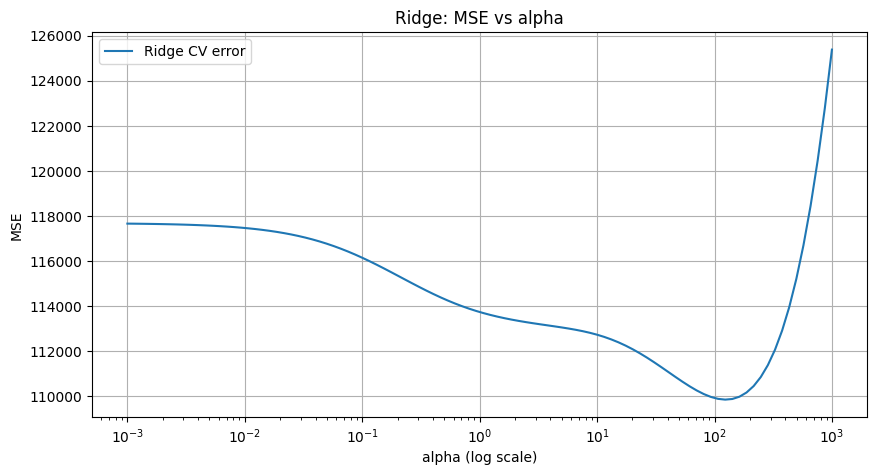

In [66]:
plt.figure(figsize=(10, 5))
plt.semilogx(alphas, np.mean(ridge_cv.cv_values_, axis=0), label="Ridge CV error")
plt.xlabel("alpha (log scale)")
plt.ylabel("MSE")
plt.title("Ridge: MSE vs alpha")
plt.grid(True)
plt.legend()
plt.show()

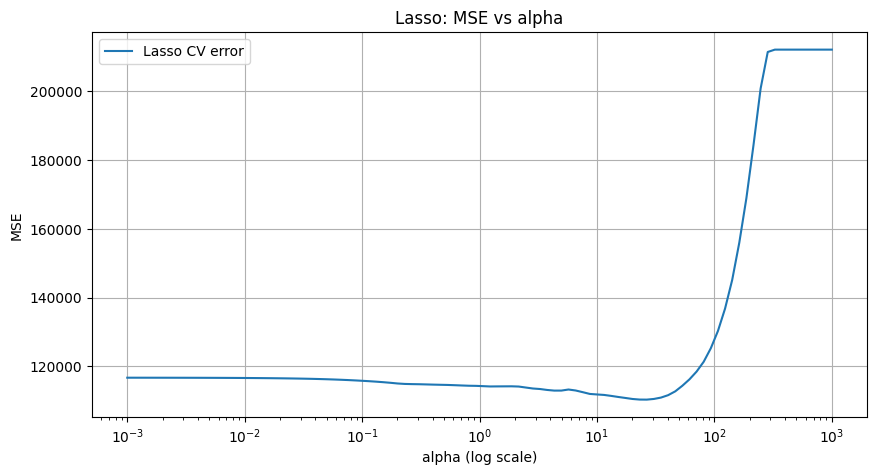

In [68]:
plt.figure(figsize=(10, 5))
plt.plot(lasso_cv.alphas_, np.mean(lasso_cv.mse_path_, axis=1), label="Lasso CV error")
plt.xscale('log')
plt.xlabel("alpha (log scale)")
plt.ylabel("MSE")
plt.title("Lasso: MSE vs alpha")
plt.grid(True)
plt.legend()
plt.show()

## Zadanie 3

In [74]:
df = pd.read_csv('wdbc.data')

In [75]:
df.head(10)

,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave_points_worst,symmetry_worst,fractal_dimension_worst
0,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.30010,0.14710,0.2419,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.08690,0.07017,0.1812,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.19740,0.12790,0.2069,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.24140,0.10520,0.2597,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.19800,0.10430,0.1809,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678
5,M,12.45,15.70,82.57,477.1,0.12780,0.17000,0.15780,0.08089,0.2087,...,15.47,23.75,103.40,741.6,0.1791,0.5249,0.5355,0.1741,0.3985,0.12440
6,M,18.25,19.98,119.60,1040.0,0.09463,0.10900,0.11270,0.07400,0.1794,...,22.88,27.66,153.20,1606.0,0.1442,0.2576,0.3784,0.1932,0.3063,0.08368
7,M,13.71,20.83,90.20,577.9,0.11890,0.16450,0.09366,0.05985,0.2196,...,17.06,28.14,110.60,897.0,0.1654,0.3682,0.2678,0.1556,0.3196,0.11510
8,M,13.00,21.82,87.50,519.8,0.12730,0.19320,0.18590,0.09353,0.2350,...,15.49,30.73,106.20,739.3,0.1703,0.5401,0.5390,0.2060,0.4378,0.10720
9,M,12.46,24.04,83.97,475.9,0.11860,0.23960,0.22730,0.08543,0.2030,...,15.09,40.68,97.65,711.4,0.1853,1.0580,1.1050,0.2210,0.4366,0.20750


In [77]:
df['diagnosis'] = df['diagnosis'].map({'B': 0, 'M': 1})

In [79]:
X = df.drop(columns=['diagnosis'])
y = df['diagnosis']

In [81]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [82]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [83]:
param_grid = {
    'penalty': ['l1', 'l2'],
    'C': np.logspace(-4, 4, 20),
    'solver': ['liblinear'], 
    'max_iter': [1000]
}

In [86]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import GridSearchCV

logreg = LogisticRegression()
grid = GridSearchCV(logreg, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid.fit(X_train_scaled, y_train)

GridSearchCV(cv=5, estimator=LogisticRegression(), n_jobs=-1,
             param_grid={'C': array([1.00000000e-04, 2.63665090e-04, 6.95192796e-04, 1.83298071e-03,
       4.83293024e-03, 1.27427499e-02, 3.35981829e-02, 8.85866790e-02,
       2.33572147e-01, 6.15848211e-01, 1.62377674e+00, 4.28133240e+00,
       1.12883789e+01, 2.97635144e+01, 7.84759970e+01, 2.06913808e+02,
       5.45559478e+02, 1.43844989e+03, 3.79269019e+03, 1.00000000e+04]),
                         'max_iter': [1000], 'penalty': ['l1', 'l2'],
                         'solver': ['liblinear']},
             scoring='accuracy')

In [87]:
best_model = grid.best_estimator_
print("Best params:", grid.best_params_)

Best params: {'C': np.float64(0.08858667904100823), 'max_iter': 1000, 'penalty': 'l2', 'solver': 'liblinear'}


In [88]:
from sklearn.metrics import accuracy_score

y_pred = best_model.predict(X_test_scaled)
test_acc = accuracy_score(y_test, y_pred)
print(f"Precision: {test_acc:.4f}")

Precision: 0.9912


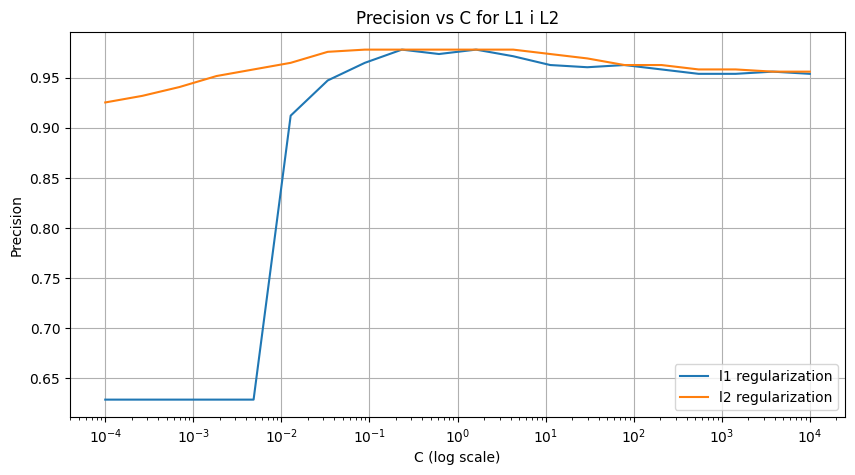

In [89]:
results = pd.DataFrame(grid.cv_results_)
plt.figure(figsize=(10, 5))

for penalty in ['l1', 'l2']:
    subset = results[results['param_penalty'] == penalty]
    plt.semilogx(subset['param_C'], subset['mean_test_score'], label=f'{penalty} regularization')

plt.xlabel("C (log scale)")
plt.ylabel("Precision")
plt.title("Precision vs C for L1 i L2")
plt.legend()
plt.grid(True)
plt.show()